In [21]:
from pathlib import Path

import hdbscan
import numpy as np
import pandas as pd
import umap
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

from visualization.plot import plot_clustering_on_umap
from visualization.samples_plot import show_clustering_samples
from clustering.consensus import consensus_clustering_from_labels
from clustering.consensus_dbcv import dbcv_per_cluster_consensus

PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")
print(embedding.shape[1])
n_samples = embedding.shape[0]

1664


In [22]:
X_reduced_variance = VarianceThreshold(threshold=1e-8).fit_transform(embedding)

embedding_scaled = StandardScaler().fit_transform(X_reduced_variance)

pca_95 = PCA(n_components=0.95, svd_solver="full")
pca_95_embedding = pca_95.fit_transform(embedding_scaled)

print("Shape dopo PCA:", pca_95_embedding.shape)

pca_95_embedding_l2 = normalize(pca_95_embedding, norm="l2")

Shape dopo PCA: (677, 315)


In [23]:
from clustering.score import consensus_param_score, consensus_param_metrics
import pandas as pd
from tqdm.auto import tqdm

from clustering.fit import fit_umap_hdbscan
from clustering.params import make_umap_hdbscan_grid_params

params = make_umap_hdbscan_grid_params(
    n_components_values=[10, 15, 20, 30],
    n_neighbors_values=[
        0.03 * n_samples,
        0.05 * n_samples,
        0.075 * n_samples,
        0.10 * n_samples,
    ],
    min_cluster_size_values=[
        0.02 * n_samples,
        0.03 * n_samples,
        0.04 * n_samples,
    ],
    min_samples_values=[
        3,
        5,
        0.01 * n_samples,
        0.015 * n_samples,
    ]
)

candidate_results = []

for config_id, param in enumerate(tqdm(params, desc="Grid search consensus")):
    labels_for_consensus = []
    umap_embeddings_for_consensus = []

    for seed in range(0, 20):
        labels, umap_embedding = fit_umap_hdbscan(
            X=pca_95_embedding_l2,
            seed=None,
            n_components=param["n_components"],
            n_neighbors=param["n_neighbors"],
            min_cluster_size=param["min_cluster_size"],
            min_samples=param["min_samples"],
        )

        labels_for_consensus.append(labels)
        umap_embeddings_for_consensus.append(umap_embedding)

    consensus_labels, probabilities = consensus_clustering_from_labels(
        labels_for_consensus,
        max_noise_frequency=0.33,
        min_consensus_strength=0.70,
    )

    dbcv_consensus = dbcv_per_cluster_consensus(
        consensus_labels,
        umap_embeddings_for_consensus,
    )

    score = consensus_param_score(
        dbcv_df=dbcv_consensus,
        consensus_labels=consensus_labels,
        max_noise=0.15,
    )

    metrics = consensus_param_metrics(
        dbcv_df=dbcv_consensus,
        consensus_labels=consensus_labels,
    )

    candidate_results.append({
        "config_id": config_id,
        **param,
        "score": score,
        **metrics,
        "consensus_labels": consensus_labels,
        "probabilities": probabilities,
        "dbcv_df": dbcv_consensus,
    })

Grid search consensus:   0%|          | 0/192 [00:00<?, ?it/s]

In [24]:
results_df = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k not in ["consensus_labels", "probabilities", "dbcv_df"]
    }
    for result in candidate_results
])

results_df = results_df.sort_values("score", ascending=False).reset_index(drop=True)

In [25]:
best_config_id = int(results_df.iloc[0]["config_id"])
best_result = candidate_results[best_config_id]

best_consensus_labels = best_result["consensus_labels"]
best_probabilities = best_result["probabilities"]
best_dbcv_df = best_result["dbcv_df"]

best_result_summary = {
    k: v
    for k, v in best_result.items()
    if k not in ["consensus_labels", "probabilities", "dbcv_df"]
}

best_result_summary

{'config_id': 41,
 'min_cluster_size': 14,
 'min_samples': 7,
 'n_components': 20,
 'n_neighbors': 34,
 'score': 0.6510360691383128,
 'n_clusters': 4,
 'noise_ratio': 0.20088626292466766,
 'global_dbcv_mean': 0.7328414013313712,
 'global_dbcv_std': 0.02190375122422791,
 'min_cluster_dbcv_median': 0.5146124030100339,
 'mean_cluster_dbcv_median': 0.7100050633234511}

In [26]:
best_cluster_dbcv = best_result["dbcv_df"]

display(
    best_cluster_dbcv[
        [
            "cluster",
            "size",
            "dbcv_mean",
            "dbcv_std",
            "dbcv_min",
            "dbcv_max",
            "dbcv_median",
            "n_runs_valid",
        ]
    ].sort_values("cluster").reset_index(drop=True)
)

,cluster,size,dbcv_mean,dbcv_std,dbcv_min,dbcv_max,dbcv_median,n_runs_valid
0,-1,136,NaN,NaN,NaN,NaN,NaN,0
1,0,43,0.823280,0.016328,0.791731,0.845833,0.825778,20
2,1,131,0.515930,0.067020,0.388455,0.660392,0.514612,20
3,2,29,0.689294,0.056722,0.562526,0.788323,0.688127,20
4,3,338,0.809141,0.027270,0.739645,0.860753,0.811503,20


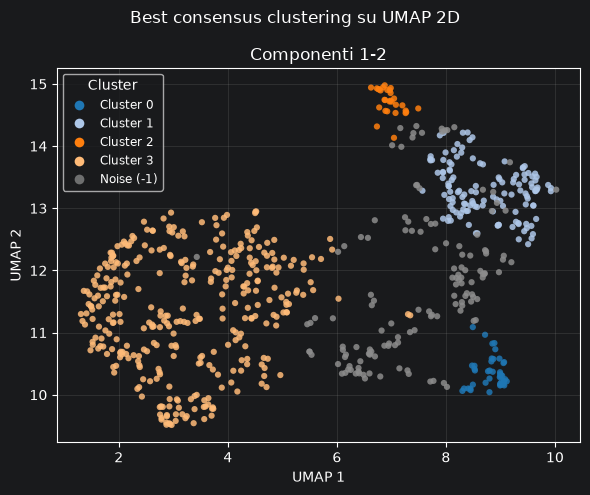

In [27]:
plot_figure, plot_axes = plot_clustering_on_umap(
    pca_95_embedding_l2,
    best_consensus_labels,
    title="Best consensus clustering su UMAP 2D",
    metric="euclidean",
    min_dist=0.05,
    n_neighbors=int(best_result["n_neighbors"]),
)

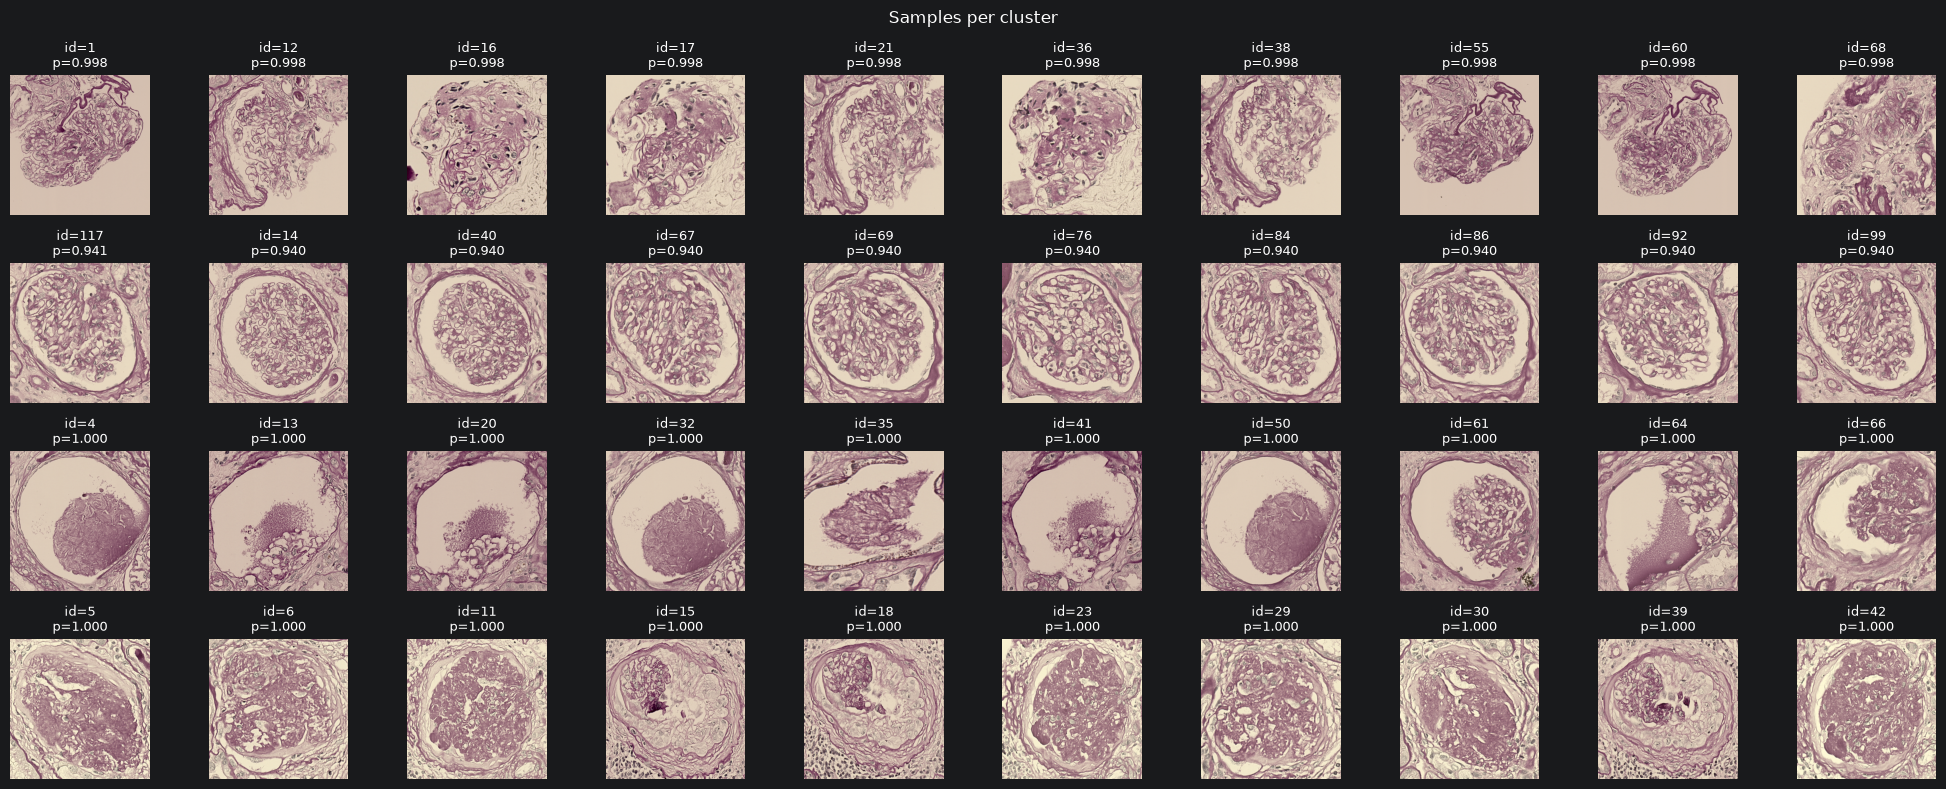

In [28]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=best_consensus_labels,
    probabilities=best_probabilities,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [29]:
from sklearn.metrics import pairwise_distances


def pair_rank_report(X, idx_a, idx_b, metric="cosine", name="space"):
    """
    Dice quanto idx_b ﷿﷿﷿﷿﷿﷿ vicino a idx_a nello spazio X.
    rank = 1 significa vicino pi﷿﷿﷿﷿﷿﷿ vicino.
    rank alto significa lontano.
    """
    D = pairwise_distances(X, X[[idx_a]], metric=metric).ravel()

    order = np.argsort(D)
    order = order[order != idx_a]  # rimuove s﷿﷿﷿﷿﷿﷿ stesso

    rank_b = np.where(order == idx_b)[0][0] + 1
    dist_ab = D[idx_b]

    percent_rank = rank_b / (len(X) - 1) * 100

    print(f"\n{name}")
    print(f"metric: {metric}")
    print(f"distanza {idx_a} -> {idx_b}: {dist_ab:.4f}")
    print(f"rank del secondo rispetto al primo: {rank_b}/{len(X) - 1}")
    print(f"percentile rank: {percent_rank:.2f}%")

    return {
        "space": name,
        "distance": dist_ab,
        "rank": rank_b,
        "percent_rank": percent_rank,
    }

In [30]:
ID_SCLEROTIC = 4
ID_OPEN = 3

In [31]:
# Distanza originale tra due punti nello spazio embedding
report_pre = pair_rank_report(
    embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="PRE-UMAP"
)

post_variance_threshold = pair_rank_report(
    X_reduced_variance,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="POST-VarianceThreshold"
)

post_pca = pair_rank_report(
    pca_95_embedding_l2,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="POST-PCA"
)

post_umap = pair_rank_report(
    umap_embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="euclidean",
    name="POST-UMAP"
)


PRE-UMAP
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-VarianceThreshold
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-PCA
metric: cosine
distanza 4 -> 3: 0.8990
rank del secondo rispetto al primo: 117/676
percentile rank: 17.31%

POST-UMAP
metric: euclidean
distanza 4 -> 3: 2.0051
rank del secondo rispetto al primo: 148/676
percentile rank: 21.89%
